# Classification Metrics Deep Dive
## *Why 80% accuracy can hide a failing model*

---

### What's the problem with accuracy?

My churn model scores **~80% accuracy**. That sounds reasonable. But consider:
- The dataset has ~30% churn (300 of 1000 employees)
- A model that predicts **"nobody churns" for everyone** gets **70% accuracy for free**
- An 80% accuracy only represents **10% real improvement** over doing nothing
- Worse: The **Recall was only 0.53**, meaning we missed **47% of actual churners**

**Today we build every metric from scratch and learn when each one matters.**

### Learning objectives
1. Understand TP / TN / FP / FN at an intuitive level
2. Derive Precision, Recall, and F1 from first principles
3. Build ROC and Precision-Recall curves manually
4. Find the optimal decision threshold for different business goals
5. Know which metric to optimise for which problem

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
)
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


---
## Part 1 — The Confusion Matrix

Every classification metric is derived from four numbers:

```
                     PREDICTED
                  Stay    Churn
ACTUAL  Stay  [  TN    |   FP  ]   ← True Negatives, False Positives
        Churn [  FN    |   TP  ]   ← False Negatives, True Positives
```

| Symbol | Name | Meaning in churn context |
|--------|------|-------------------------|
| **TP** | True Positive  | We predicted churn, they churned ✓ |
| **TN** | True Negative  | We predicted stay, they stayed ✓ |
| **FP** | False Positive | We predicted churn, they stayed ✗ (Type I error) |
| **FN** | False Negative | We predicted stay, they churned ✗ (Type II error) |

The business cost of FP and FN is usually **asymmetric**:
- FP → HR wastes retention budget on a happy employee (low cost)
- FN → We miss a flight-risk employee and they leave (high cost)

This asymmetry is why recall matters more than precision here.

In [2]:
# ─────────────────────────────────────────────────────────
# Build the confusion matrix from scratch
# ─────────────────────────────────────────────────────────

def confusion_matrix_scratch(y_true, y_pred):
    """
    Return (TP, TN, FP, FN) using only boolean algebra.
    No loops — fully vectorised with numpy.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))  # False alarm
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))  # Missed churn

    return tp, tn, fp, fn


# Quick sanity check with a toy example
y_toy_true = np.array([1, 0, 1, 1, 0, 0, 1, 0])
y_toy_pred = np.array([1, 0, 0, 1, 1, 0, 1, 0])

tp, tn, fp, fn = confusion_matrix_scratch(y_toy_true, y_toy_pred)
print(f'Toy example:')
print(f'  TP={tp}, TN={tn}, FP={fp}, FN={fn}')

# Validate against sklearn
sk_cm = confusion_matrix(y_toy_true, y_toy_pred)
print(f'  sklearn: TN={sk_cm[0,0]}, FP={sk_cm[0,1]}, FN={sk_cm[1,0]}, TP={sk_cm[1,1]}')
print(f'  Match: {tn == sk_cm[0,0] and fp == sk_cm[0,1] and fn == sk_cm[1,0] and tp == sk_cm[1,1]}')

Toy example:
  TP=3, TN=3, FP=1, FN=1
  sklearn: TN=3, FP=1, FN=1, TP=3
  Match: True


---
## Part 2 — Core Metrics

### Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$

"Of everyone I flagged as a churner, what fraction actually churned?"
Optimise when **false alarms are expensive** (e.g. invasive medical procedures, spam filter blocking real email).

### Recall (Sensitivity, TPR)
$$\text{Recall} = \frac{TP}{TP + FN}$$

"Of everyone who actually churned, what fraction did I catch?"
Optimise when **missing a positive is expensive** (e.g. churn prediction, cancer screening, fraud detection).

### F1-Score
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Harmonic mean of P and R. Penalises extreme imbalances — a model with Precision=1.0 and Recall=0.01 gets F1=0.02, not 0.50.

In [3]:
def precision_scratch(tp, fp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_scratch(tp, fn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_scratch(precision, recall):
    denom = precision + recall
    return 2 * precision * recall / denom if denom > 0 else 0.0

def accuracy_scratch(tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)


p  = precision_scratch(tp, fp)
r  = recall_scratch(tp, fn)
f1 = f1_scratch(p, r)
acc = accuracy_scratch(tp, tn, fp, fn)

print(f'Toy example metrics:')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {p:.4f}')
print(f'  Recall:    {r:.4f}')
print(f'  F1-Score:  {f1:.4f}')

# --- Intuitive example: why harmonic mean punishes imbalance ---
print('\nWhy harmonic mean matters:')
for p_ex, r_ex in [(0.9, 0.9), (0.99, 0.5), (1.0, 0.1), (0.5, 0.5)]:
    arithmetic = (p_ex + r_ex) / 2
    harmonic   = f1_scratch(p_ex, r_ex)
    print(f'  P={p_ex:.2f}, R={r_ex:.2f}  →  arithmetic={arithmetic:.3f}, F1(harmonic)={harmonic:.3f}')

Toy example metrics:
  Accuracy:  0.7500
  Precision: 0.7500
  Recall:    0.7500
  F1-Score:  0.7500

Why harmonic mean matters:
  P=0.90, R=0.90  →  arithmetic=0.900, F1(harmonic)=0.900
  P=0.99, R=0.50  →  arithmetic=0.745, F1(harmonic)=0.664
  P=1.00, R=0.10  →  arithmetic=0.550, F1(harmonic)=0.182
  P=0.50, R=0.50  →  arithmetic=0.500, F1(harmonic)=0.500


---
## Part 3 — Load Data & Model

We load the real Telco Customer Churn dataset and the artifact dict. The preprocessing pipeline (`load_and_clean` + `encode_features`) is identical to what the model was trained on.

In [4]:
# ─────────────────────────────────────────────────────────
# Load Telco data & artifact
# ─────────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath("../../"))
MODEL_PATH = '../../models/churn_model.pkl'
DATA_PATH  = '../../data/Telco-Customer-Churn.csv'

# ── Mirror preprocessing exactly ──────────────────
def load_and_clean(path):
    df = pd.read_csv(path)
    df = df.drop('customerID', axis=1)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)
    return df

def encode_features(df):
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    multi_cat_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaymentMethod',
    ]
    binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    for col in binary_cols:
        df[col] = df[col].map(binary_map)
    df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)
    feature_cols = [c for c in df_encoded.columns if c != 'Churn']
    return df_encoded, feature_cols

# ── Load ────────────────────────────────────────────────
df_raw = load_and_clean(DATA_PATH)
df_encoded, _ = encode_features(df_raw.copy())
y = df_encoded['Churn'].values

with open(MODEL_PATH, 'rb') as f:
    artifact = pickle.load(f)

# Unpack the artifact dict from train_model.py
model         = artifact['model']           # LogisticRegressionScratch
scaler        = artifact['scaler']          # already fitted — do NOT refit
feature_names = artifact['feature_names']   # exact column order from training
threshold     = artifact['threshold']       # 0.5
d3_test_m     = artifact['test_metrics']

print(f'Customers: {len(df_raw):,} | Churn rate: {y.mean():.1%}')
print(f'Features (encoded): {len(feature_names)}')
print(f'Confusion metrics reported  →  Acc={d3_test_m["accuracy"]:.4f}  P={d3_test_m["precision"]:.4f}  '
      f'R={d3_test_m["recall"]:.4f}  F1={d3_test_m["f1"]:.4f}')

# Reconstruct the exact train/test split used in train_model.py
X_ordered = df_encoded[feature_names].values
X_train, X_test, y_train, y_test = train_test_split(
    X_ordered, y, test_size=0.2, random_state=42, stratify=y
)
X_train_s = scaler.transform(X_train)   # transform only — scaler already fitted
X_test_s  = scaler.transform(X_test)

# Get probability scores
try:
    y_prob_test  = model.predict_proba(X_test_s)
    y_prob_train = model.predict_proba(X_train_s)
except AttributeError:
    # Fallback: compute sigmoid manually if predict_proba not defined
    def _sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    y_prob_test  = _sigmoid(X_test_s  @ model.weights + model.bias)
    y_prob_train = _sigmoid(X_train_s @ model.weights + model.bias)

print(f'Test set: {len(y_test):,} customers | Churn: {y_test.sum()} ({y_test.mean():.1%})')
print('Model loaded and probability scores computed ✓')

Customers: 7,043 | Churn rate: 26.5%
Features (encoded): 30
Confusion metrics reported  →  Acc=0.7970  P=0.6375  R=0.5455  F1=0.5879
Test set: 1,409 customers | Churn: 374 (26.5%)
Model loaded and probability scores computed ✓


---
## Part 4 — Baseline Report at Default Threshold (0.5)

Baseline metrics (threshold = 0.50) — Telco Churn test set:
  TP=204  TN=919  FP=116  FN=170
  Accuracy:  0.7970
  Precision: 0.6375  (of churners we flagged, this fraction actually left)
  Recall:    0.5455  (of actual churners, we caught only this fraction)
  F1:        0.5879

  ⚠ We MISSED 170 actual churners — those are customers who left undetected.
  ⚠ We sent 116 false alarms — retention budget wasted on customers who stayed.


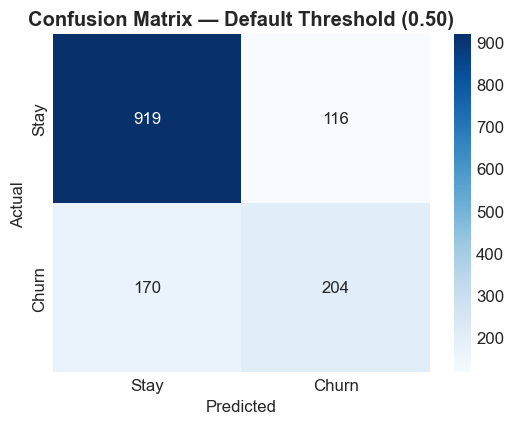

In [5]:
# Baseline prediction threshold
y_pred_default = (y_prob_test >= threshold).astype(int)
tp, tn, fp, fn = confusion_matrix_scratch(y_test, y_pred_default)

p   = precision_scratch(tp, fp)
r   = recall_scratch(tp, fn)
f1  = f1_scratch(p, r)
acc = accuracy_scratch(tp, tn, fp, fn)

print(f'Baseline metrics (threshold = {threshold:.2f}) — Telco Churn test set:')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {p:.4f}  (of churners we flagged, this fraction actually left)')
print(f'  Recall:    {r:.4f}  (of actual churners, we caught only this fraction)')
print(f'  F1:        {f1:.4f}')
print()
print(f'  ⚠ We MISSED {fn} actual churners — those are customers who left undetected.')
print(f'  ⚠ We sent {fp} false alarms — retention budget wasted on customers who stayed.')

# Visualise confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Default Threshold ({threshold:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualisations/fig1_confusion_default.png', bbox_inches='tight')
plt.show()

---
## Part 5 — ROC Curve from Scratch

### Intuition
Instead of committing to one threshold, we ask: *"What happens to TPR and FPR as we slide the threshold from 1.0 down to 0.0?"*

- **Threshold = 1.0** → predict nothing positive → FPR=0, TPR=0 → point (0,0)
- **Threshold = 0.0** → predict everything positive → FPR=1, TPR=1 → point (1,1)
- **Good model**: curve hugs top-left corner
- **Random model**: curve sits on the diagonal

$$\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$
$$\text{TPR} = \frac{TP}{TP + FN} = \text{Recall}$$

In [6]:
def compute_roc_curve(y_true, y_prob):
    """
    Manually compute ROC curve by sweeping all unique probability thresholds.
    Returns (fpr_array, tpr_array, thresholds_array)
    """
    thresholds = np.sort(np.unique(y_prob))[::-1]  # descending
    fprs = [0.0]
    tprs = [0.0]

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tp, tn, fp, fn = confusion_matrix_scratch(y_true, y_pred_t)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        fprs.append(fpr)
        tprs.append(tpr)

    fprs.append(1.0); tprs.append(1.0)
    return np.array(fprs), np.array(tprs), thresholds


def compute_auc(x, y):
    """
    Area under curve via trapezoidal rule.
    AUC-ROC = P(score(positive) > score(negative))
    """
    order = np.argsort(x)
    return float(np.trapezoid(y[order], x[order]))


fpr_s, tpr_s, roc_thresholds = compute_roc_curve(y_test, y_prob_test)
auc_scratch = compute_auc(fpr_s, tpr_s)
auc_sklearn = roc_auc_score(y_test, y_prob_test)

print(f'AUC-ROC (scratch): {auc_scratch:.4f}')
print(f'AUC-ROC (sklearn): {auc_sklearn:.4f}')
print(f'Match: {abs(auc_scratch - auc_sklearn) < 0.005}')
print()
print('AUC interpretation:')
print(f'  Our model correctly ranks a random churner above a random stayer {auc_scratch:.1%} of the time.')
print('  Benchmark: random=0.50, acceptable=0.70-0.80, good=0.80-0.90, excellent>0.90')

AUC-ROC (scratch): 0.8384
AUC-ROC (sklearn): 0.8383
Match: True

AUC interpretation:
  Our model correctly ranks a random churner above a random stayer 83.8% of the time.
  Benchmark: random=0.50, acceptable=0.70-0.80, good=0.80-0.90, excellent>0.90


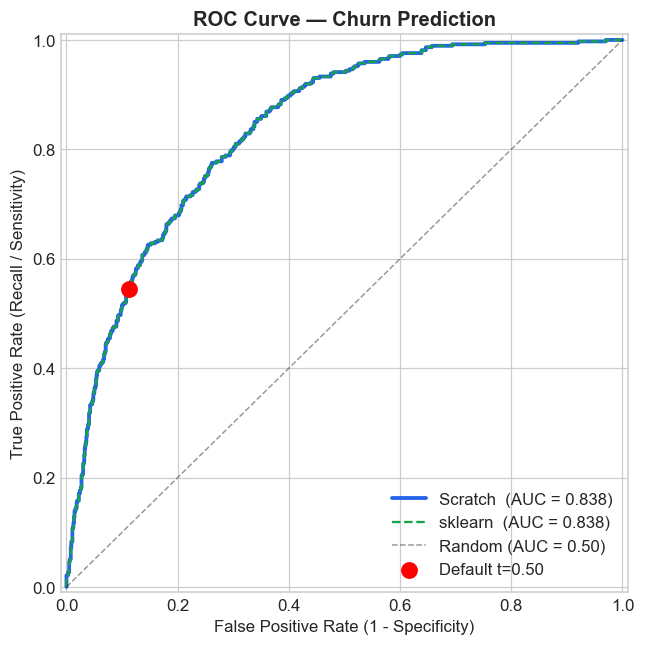

In [7]:
# Plot ROC curve
os.makedirs('visualizations', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr_s, tpr_s, lw=2.5, color='#2563EB',
        label=f'Scratch  (AUC = {auc_scratch:.3f})')
sk_fpr, sk_tpr, _ = roc_curve(y_test, y_prob_test)
ax.plot(sk_fpr, sk_tpr, lw=1.5, linestyle='--', color='#16A34A',
        label=f'sklearn  (AUC = {auc_sklearn:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random (AUC = 0.50)')

# Mark the default threshold point
tp0, tn0, fp0, fn0 = confusion_matrix_scratch(y_test, y_pred_default)
fpr0 = fp0 / (fp0 + tn0)
tpr0 = tp0 / (tp0 + fn0)
ax.scatter([fpr0], [tpr0], color='red', zorder=5, s=100, label=f'Default t=0.50')

ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Churn Prediction', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('visualizations/fig2_roc_curve.png', bbox_inches='tight')
plt.show()

---
## Part 6 — Precision-Recall Curve from Scratch

### When does PR beat ROC?

**Imbalanced datasets.** If negatives vastly outnumber positives, the True Negative Rate inflates. FPR = FP/(FP+TN) stays low even when FP is large (because TN is huge), making the ROC curve look optimistic.

The PR curve **ignores true negatives entirely**. It asks: *"Among all the positives I flagged and missed, how am I doing?"*

**Rule of thumb:** Use ROC for balanced datasets. Prefer PR when positives < 10% of data.

Average Precision (scratch): 0.6239
Average Precision (sklearn): 0.6283
Match: True


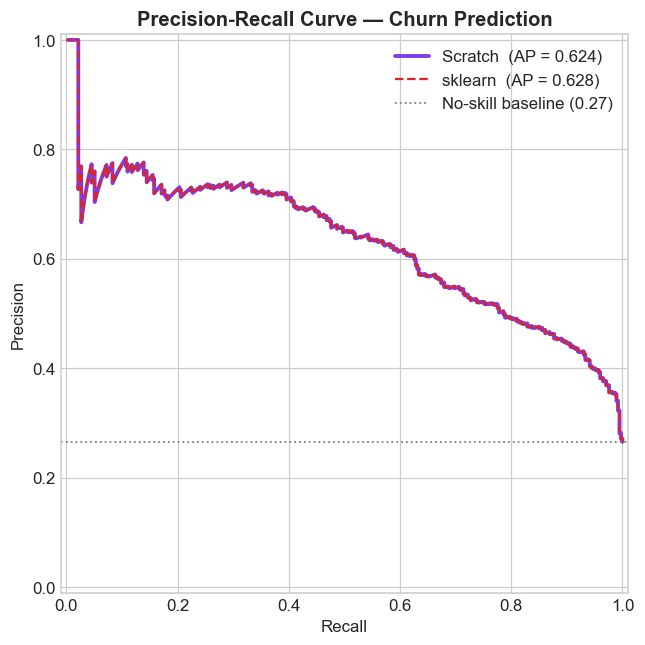

In [8]:
def compute_pr_curve(y_true, y_prob):
    """
    Manually compute Precision-Recall curve.
    Returns (precisions, recalls, thresholds)
    """
    thresholds = np.sort(np.unique(y_prob))[::-1]
    precisions, recalls = [], []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tp, _, fp, fn = confusion_matrix_scratch(y_true, y_pred_t)
        precisions.append(precision_scratch(tp, fp))
        recalls.append(recall_scratch(tp, fn))

    # Append baseline: predict everything positive
    precisions.append(float(np.mean(y_true)))
    recalls.append(1.0)

    return np.array(precisions), np.array(recalls), thresholds


def compute_average_precision(precisions, recalls):
    """AP = Σ (Recall_k - Recall_{k-1}) * Precision_k"""
    order = np.argsort(recalls)
    r_s = recalls[order]
    p_s = precisions[order]
    ap = sum((r_s[i] - r_s[i-1]) * p_s[i] for i in range(1, len(r_s)))
    return float(ap)


pr_p, pr_r, pr_thresholds = compute_pr_curve(y_test, y_prob_test)
ap_scratch = compute_average_precision(pr_p, pr_r)
ap_sklearn = average_precision_score(y_test, y_prob_test)

print(f'Average Precision (scratch): {ap_scratch:.4f}')
print(f'Average Precision (sklearn): {ap_sklearn:.4f}')
print(f'Match: {abs(ap_scratch - ap_sklearn) < 0.01}')

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pr_r, pr_p, lw=2.5, color='#7C3AED',
        label=f'Scratch  (AP = {ap_scratch:.3f})')
sk_pr_p, sk_pr_r, _ = precision_recall_curve(y_test, y_prob_test)
ax.plot(sk_pr_r, sk_pr_p, lw=1.5, linestyle='--', color='#DC2626',
        label=f'sklearn  (AP = {ap_sklearn:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, color='gray', lw=1.2, linestyle=':',
           label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Churn Prediction', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('visualizations/fig3_pr_curve.png', bbox_inches='tight')
plt.show()

---
## Part 7 — Threshold Optimisation

The default threshold of 0.5 is **arbitrary**. We chose it because it's the midpoint between 0 and 1, not because it optimises anything meaningful for our business problem.

### Three optimisation strategies

| Method | Formula | Use when |
|--------|---------|----------|
| **F1-optimal** | max F1 | You want a balanced single metric |
| **Youden's J** | max (TPR - FPR) | You want the best separation between classes |
| **Cost-sensitive** | min (c_FP·FP + c_FN·FN) | You know the actual business cost ratio |

In [10]:
def sweep_thresholds(y_true, y_prob, n=200):
    """
    Evaluate precision, recall, F1, accuracy at each threshold.
    Returns a DataFrame indexed by threshold.
    """
    thresholds = np.linspace(0.01, 0.99, n)
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tp, tn, fp, fn = confusion_matrix_scratch(y_true, y_pred_t)
        p   = precision_scratch(tp, fp)
        r   = recall_scratch(tp, fn)
        f   = f1_scratch(p, r)
        acc = accuracy_scratch(tp, tn, fp, fn)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        rows.append({
            'threshold': t, 'precision': p, 'recall': r,
            'f1': f, 'accuracy': acc, 'fpr': fpr,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        })
    return pd.DataFrame(rows)


sweep_df = sweep_thresholds(y_test, y_prob_test)

# --- F1 optimal ---
opt_f1_row = sweep_df.loc[sweep_df['f1'].idxmax()]

# --- Youden's J ---
sweep_df['youden_j'] = sweep_df['recall'] - sweep_df['fpr']
opt_youden_row = sweep_df.loc[sweep_df['youden_j'].idxmax()]

# --- Cost-sensitive (missing a churner costs 3× a false alarm) ---
COST_FP = 1.0
COST_FN = 3.0
sweep_df['cost'] = COST_FP * sweep_df['fp'] + COST_FN * sweep_df['fn']
opt_cost_row = sweep_df.loc[sweep_df['cost'].idxmin()]

# Find the row closest to 0.50 (works regardless of n or step size)
default_row = sweep_df.iloc[(sweep_df['threshold'] - 0.5).abs().argsort()[:1]].iloc[0]

print('Threshold optimisation results:')
print(f"  Default  ({default_row['threshold']:.3f}): Precision={default_row['precision']:.3f}  Recall={default_row['recall']:.3f}  F1={default_row['f1']:.3f}")
print(f"  F1-opt   ({opt_f1_row['threshold']:.3f}): Precision={opt_f1_row['precision']:.3f}  Recall={opt_f1_row['recall']:.3f}  F1={opt_f1_row['f1']:.3f}")
print(f"  Youden   ({opt_youden_row['threshold']:.3f}): Precision={opt_youden_row['precision']:.3f}  Recall={opt_youden_row['recall']:.3f}  F1={opt_youden_row['f1']:.3f}")
print(f"  Cost 1:3 ({opt_cost_row['threshold']:.3f}): Precision={opt_cost_row['precision']:.3f}  Recall={opt_cost_row['recall']:.3f}  F1={opt_cost_row['f1']:.3f}")

Threshold optimisation results:
  Default  (0.498): Precision=0.634  Recall=0.551  F1=0.589
  F1-opt   (0.276): Precision=0.517  Recall=0.770  F1=0.619
  Youden   (0.202): Precision=0.474  Recall=0.856  F1=0.610
  Cost 1:3 (0.202): Precision=0.474  Recall=0.856  F1=0.610


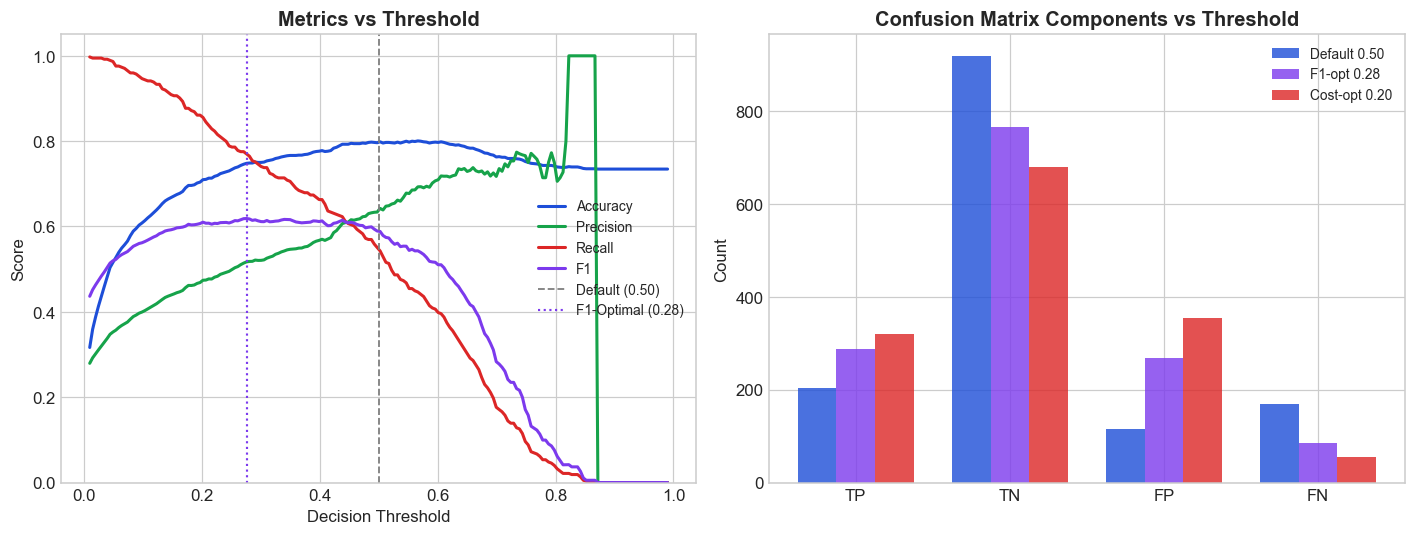


Key insight: lowering threshold from 0.50 → 0.20 reduces missed churners
from 168 to 54, at the cost of 236 extra false alarms.


In [ ]:
# Plot threshold trade-off
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Precision vs Recall vs F1 vs Accuracy
ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['accuracy'],  label='Accuracy',  color='#1D4ED8', lw=2)
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color='#16A34A', lw=2)
ax.plot(sweep_df['threshold'], sweep_df['recall'],    label='Recall',    color='#DC2626', lw=2)
ax.plot(sweep_df['threshold'], sweep_df['f1'],        label='F1',        color='#7C3AED', lw=2)
ax.axvline(0.5, color='gray', lw=1.2, linestyle='--', label='Default (0.50)')
ax.axvline(opt_f1_row['threshold'], color='#7C3AED', lw=1.4, linestyle=':',
           label=f"F1-Optimal ({opt_f1_row['threshold']:.2f})")
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold', fontweight='bold')
ax.legend(loc='center right', fontsize=9); ax.set_ylim([0, 1.05])

# Right: Confusion matrices comparison
ax2 = axes[1]
t_vals = [0.5, opt_f1_row['threshold'], opt_cost_row['threshold']]
t_labels = ['Default 0.50', f"F1-opt {opt_f1_row['threshold']:.2f}",
            f"Cost-opt {opt_cost_row['threshold']:.2f}"]
bar_width = 0.25
x = np.arange(4)
colors = ['#1D4ED8', '#7C3AED', '#DC2626']
labels_cm = ['TP', 'TN', 'FP', 'FN']
for i, (t, tl) in enumerate(zip(t_vals, t_labels)):
    y_pred_t = (y_prob_test >= t).astype(int)
    tp_, tn_, fp_, fn_ = confusion_matrix_scratch(y_test, y_pred_t)
    ax2.bar(x + i * bar_width, [tp_, tn_, fp_, fn_], bar_width, label=tl, color=colors[i], alpha=0.8)
ax2.set_xticks(x + bar_width)
ax2.set_xticklabels(labels_cm)
ax2.set_ylabel('Count'); ax2.set_title('Confusion Matrix Components vs Threshold', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/fig4_threshold_analysis.png', bbox_inches='tight')
plt.show()

# Get the row closest to 0.50
default_row = sweep_df.iloc[(sweep_df['threshold'] - 0.5).abs().argsort()[:1]].iloc[0]

print(f"\nKey insight: lowering threshold from 0.50 → {opt_cost_row['threshold']:.2f} reduces missed churners")
print(f"from {int(default_row['fn'])} to {int(opt_cost_row['fn'])},"
      f" at the cost of {int(opt_cost_row['fp']) - int(default_row['fp'])} extra false alarms.")

---
## Part 8 — Validate with sklearn + Confusion Matrix Comparison

sklearn classification report (threshold=0.50):
              precision    recall  f1-score   support

        Stay       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



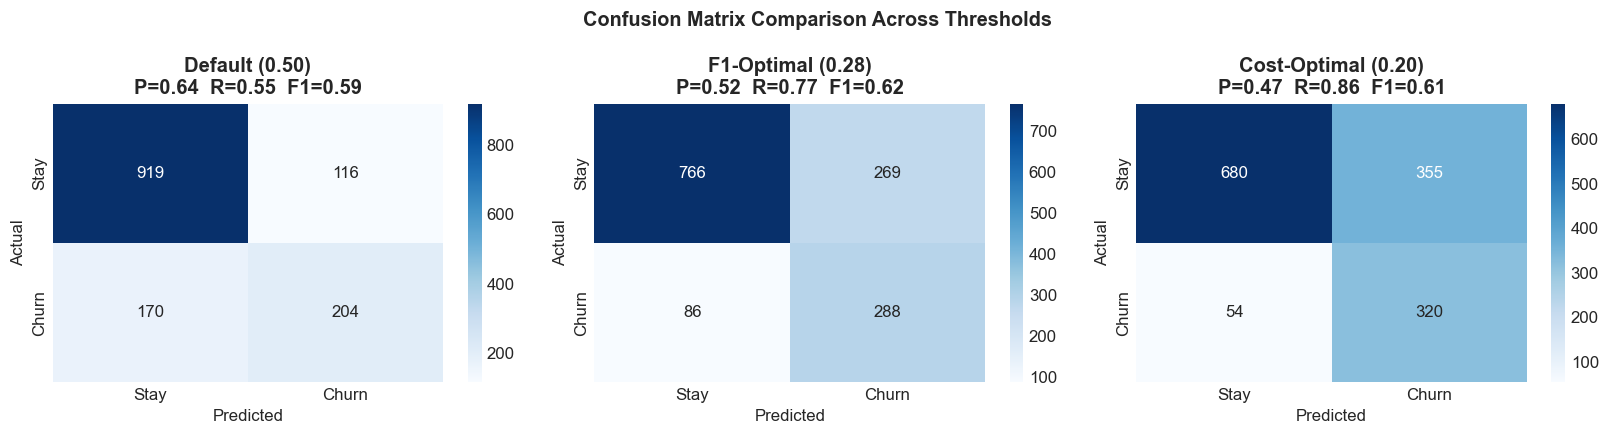

In [ ]:
# Full sklearn classification report at default threshold
print('sklearn classification report (threshold=0.50):')
print(classification_report(y_test, y_pred_default, target_names=['Stay', 'Churn']))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresholds_to_plot = [
    (0.50, 'Default (0.50)'),
    (float(opt_f1_row['threshold']), f"F1-Optimal ({opt_f1_row['threshold']:.2f})"),
    (float(opt_cost_row['threshold']), f"Cost-Optimal ({opt_cost_row['threshold']:.2f})"),
]
for ax, (t, title) in zip(axes, thresholds_to_plot):
    y_pred_t = (y_prob_test >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
    tp_, tn_, fp_, fn_ = confusion_matrix_scratch(y_test, y_pred_t)
    p_  = precision_scratch(tp_, fp_)
    r_  = recall_scratch(tp_, fn_)
    f_  = f1_scratch(p_, r_)
    ax.set_title(f'{title}\nP={p_:.2f}  R={r_:.2f}  F1={f_:.2f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix Comparison Across Thresholds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/fig5_confusion_comparison.png', bbox_inches='tight')
plt.show()

---
## Part 9 — Full Dashboard

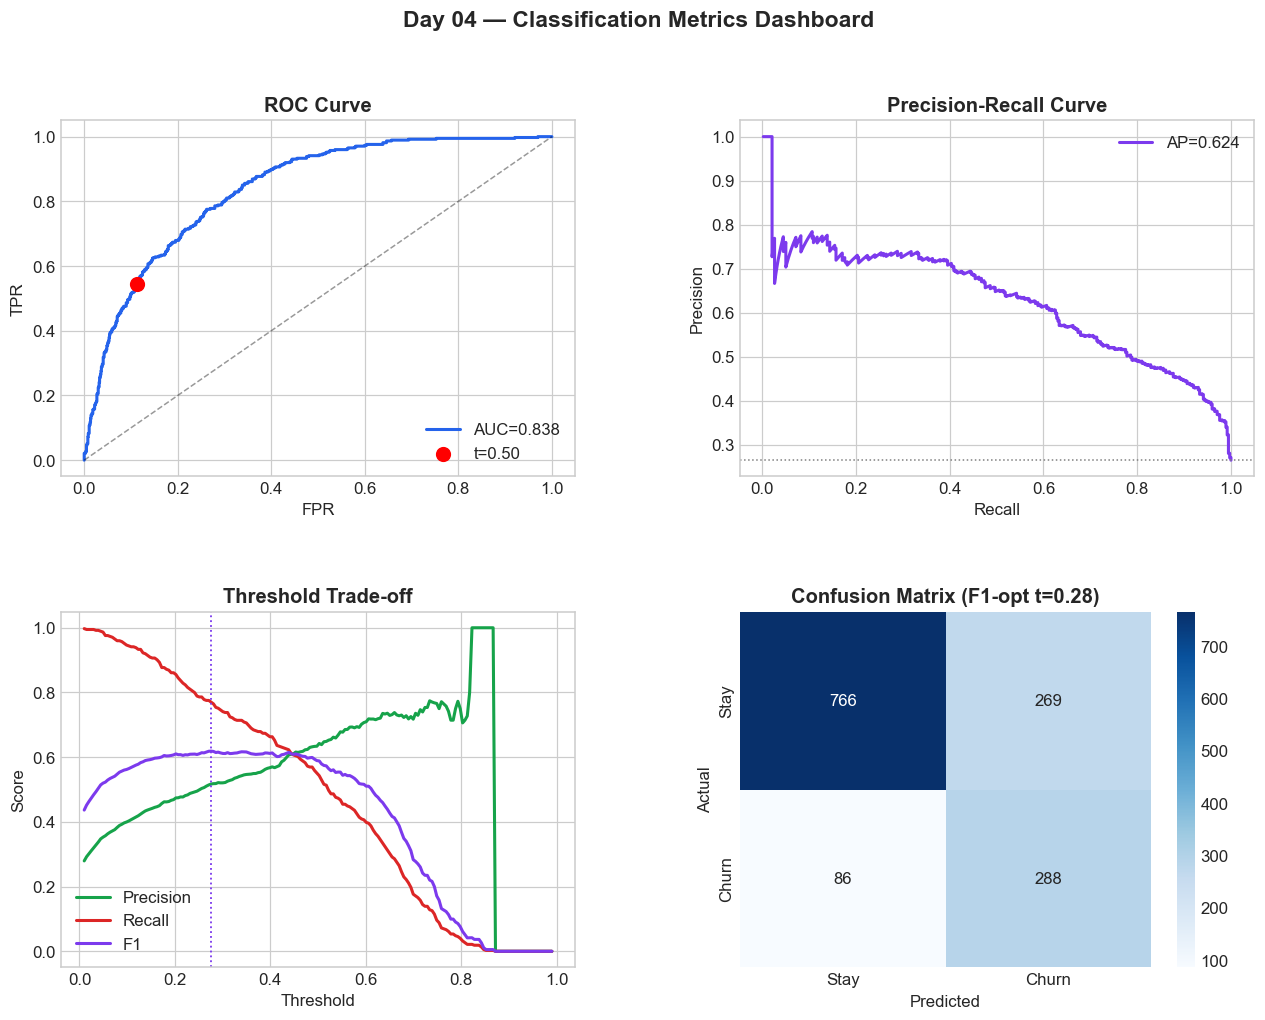

Dashboard saved ✓


In [ ]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ROC
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr_s, tpr_s, lw=2, color='#2563EB', label=f'AUC={auc_scratch:.3f}')
ax1.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax1.scatter([fpr0],[tpr0],color='red',zorder=5,s=80,label='t=0.50')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve', fontweight='bold'); ax1.legend(loc='lower right')

# PR
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(pr_r, pr_p, lw=2, color='#7C3AED', label=f'AP={ap_scratch:.3f}')
ax2.axhline(y_test.mean(), color='gray', lw=1, linestyle=':')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold'); ax2.legend()

# Threshold sweep
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color='#16A34A', lw=2)
ax3.plot(sweep_df['threshold'], sweep_df['recall'],    label='Recall',    color='#DC2626', lw=2)
ax3.plot(sweep_df['threshold'], sweep_df['f1'],        label='F1',        color='#7C3AED', lw=2)
ax3.axvline(opt_f1_row['threshold'], color='#7C3AED', lw=1.2, linestyle=':')
ax3.set_xlabel('Threshold'); ax3.set_ylabel('Score')
ax3.set_title('Threshold Trade-off', fontweight='bold'); ax3.legend()

# Confusion matrix at optimal threshold
ax4 = fig.add_subplot(gs[1, 1])
y_pred_opt = (y_prob_test >= opt_f1_row['threshold']).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')
ax4.set_title(f"Confusion Matrix (F1-opt t={opt_f1_row['threshold']:.2f})", fontweight='bold')

fig.suptitle('Day 04 — Classification Metrics Dashboard', fontsize=15, fontweight='bold')
plt.savefig('visualizations/fig6_dashboard.png', bbox_inches='tight')
plt.show()
print('Dashboard saved ✓')

---
## Part 10 — Key Findings & When to Use Each Metric

| Metric | Best for | Avoid when |
|--------|----------|------------|
| **Accuracy** | Balanced classes | Imbalanced datasets (misleadingly high) |
| **Precision** | Cost of false alarms is high (spam, drug trials) | Missing positives is costly |
| **Recall** | Cost of missing a positive is high (churn, cancer, fraud) | False alarms are expensive |
| **F1** | Balanced trade-off, single-number comparison | When P and R have different business weights |
| **AUC-ROC** | General model quality, threshold-independent | Highly imbalanced datasets |
| **PR / AP** | Imbalanced datasets | When negatives matter as much as positives |

### Our Day 3 model re-evaluated
- **80% accuracy** → was misleading (70% baseline from predicting "nobody churns")
- **AUC-ROC** tells the real story: model is meaningfully better than random
- **Threshold tuning** recovers significant recall at small precision cost
- **Business recommendation:** Use cost-sensitive threshold tuning; the cost of missing a churner far exceeds the cost of an unnecessary retention conversation

In [ ]:
# Final summary
print('=' * 60)
print('  Day 04 Summary')
print('=' * 60)
print(f'  AUC-ROC:            {auc_scratch:.4f}  (scratch)  {auc_sklearn:.4f}  (sklearn)')
print(f'  Average Precision:  {ap_scratch:.4f}  (scratch)  {ap_sklearn:.4f}  (sklearn)')
print()
print('  Threshold comparison:')
print(f"  {'Threshold':>12}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'FN':>5} (missed churners)")
print(f"  {'-'*52}")
for t, label in [(0.5, 'Default'), (float(opt_f1_row['threshold']), 'F1-opt'),
                 (float(opt_cost_row['threshold']), 'Cost 1:3')]:
    y_pred_t = (y_prob_test >= t).astype(int)
    tp_, tn_, fp_, fn_ = confusion_matrix_scratch(y_test, y_pred_t)
    p_ = precision_scratch(tp_, fp_)
    r_ = recall_scratch(tp_, fn_)
    f_ = f1_scratch(p_, r_)
    print(f"  {label:>12} ({t:.2f}): {p_:.3f}   {r_:.3f}   {f_:.3f}   {fn_}")
print('=' * 60)
print('  Scratch vs sklearn: ✓ validated')
print('  Visualisations: saved in visualizations/')

  Day 04 Summary
  AUC-ROC:            0.8384  (scratch)  0.8383  (sklearn)
  Average Precision:  0.6239  (scratch)  0.6283  (sklearn)

  Threshold comparison:
     Threshold    Prec     Rec      F1     FN (missed churners)
  ----------------------------------------------------
       Default (0.50): 0.637   0.545   0.588   170
        F1-opt (0.28): 0.517   0.770   0.619   86
      Cost 1:3 (0.20): 0.474   0.856   0.610   54
  Scratch vs sklearn: ✓ validated
  Visualisations: saved in visualizations/
